Проведем практическую пошаговую реализацию сверточной нейронной сети (CNN) для классификации изображений с использованием PyTorch на наборе данных CIFAR-10.

# Импорт библиотек

In [44]:
import sys
import subprocess
print(sys.executable)
subprocess.run([sys.executable, "-m", "pip", "install", "numpy==1.26.4"])
import numpy
print(numpy.__version__)

/Library/Developer/CommandLineTools/usr/bin/python3
Defaulting to user installation because normal site-packages is not writeable
1.26.4


In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

Определение преобразований данных и загрузка CIFAR-10

Мы определяем преобразование нормализации, масштабируя значения пикселей таким образом, чтобы среднее значение составляло 0,5, а стандартное отклонение — 0,5 для каждого канала. Затем мы загружаем набор данных CIFAR-10 как для обучения, так и для тестирования, применяя это преобразование.

Подсказка: torchvision для получения данных. Compose для преобразований. Учитываем, что каналов 3.

In [46]:
torch.manual_seed(42)
np.random.seed(42)

In [47]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [48]:
train_dataset = datasets.CIFAR10('./data', train=True, transform=transform, download=True)
test_dataset = datasets.CIFAR10('./data', train=False, transform=transform, download=True)

Files already downloaded and verified
Files already downloaded and verified


# Создание Data Loaders

Установите размер батча в 128. Создайте DataLoaders как для тренировочной, так и для тестовых выборок.

In [49]:
train_loaders = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loaders = DataLoader(test_dataset, batch_size=128, shuffle=True)

# Визуализируем наши данные

Получите пакет изображений и меток из загрузчика обучающих данных.
Отобразите сетку из 25 обучающих изображений для визуального подтверждения конвейера обработки данных.

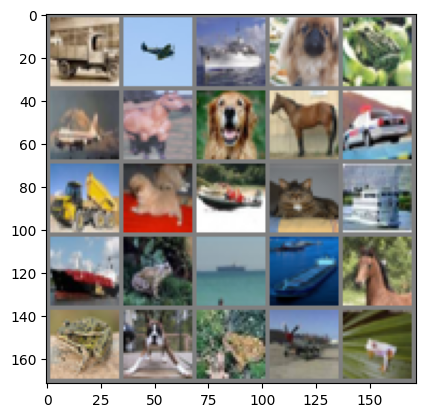

In [53]:
images, labels = next(iter(train_loaders))
images = images[:25]
labels = labels[:25]
grid = torchvision.utils.make_grid(images, nrow=5)
grid = grid / 2 + 0.5
plt.imshow(grid.permute(1, 2, 0))
# title = ' '.join(train_dataset.classes[label] for label in labels)
# plt.title(title)
plt.show()

l# Анализ классов по распределениям

Соберите все метки классов из обучающих данных.
Подсчитайте количество вхождений каждого класса и визуализируйте с помощью столбчатой ​​диаграммы, показывающей баланс классов.

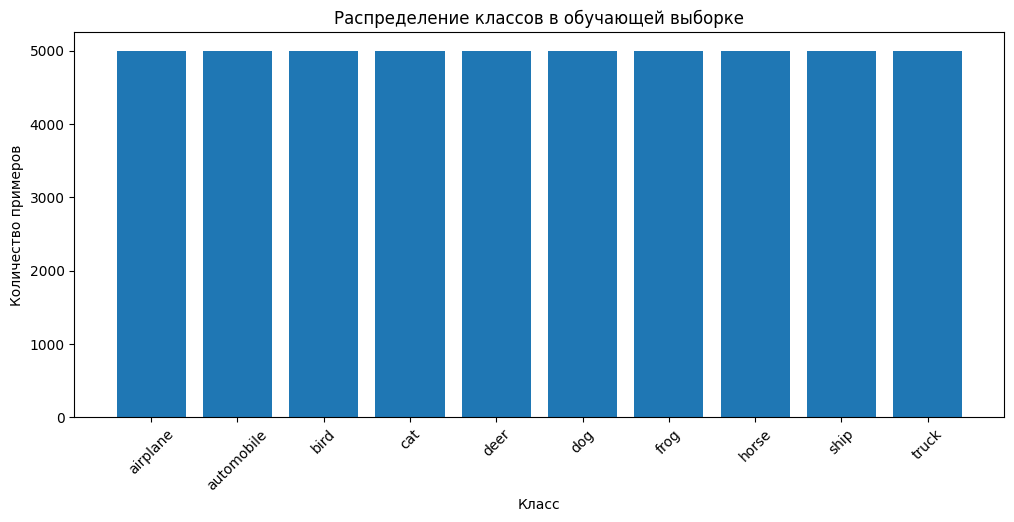

In [60]:
all_labels = [label for _, label in train_dataset]
unique, counts = np.unique(all_labels, return_counts=True)
plt.figure(figsize=(12, 5))
plt.bar(unique, counts)
plt.xlabel('Класс')
plt.ylabel('Количество примеров')
plt.title('Распределение классов в обучающей выборке')
if hasattr(train_dataset, 'classes'):
    plt.xticks(unique, [train_dataset.classes[i] for i in unique], rotation=45)
else:
    plt.xticks(unique)
plt.show()

## Вывод

В ходе выполнения задания были собраны все метки классов из обучающих данных, подсчитано количество примеров для каждого класса и построена столбчатая диаграмма, визуализирующая распределение классов.

Анализ показал, что обучающая выборка содержит 10 классов (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck), каждый из которых представлен 5000 изображениями. Это свидетельствует о сбалансированности классов.

# Построение архитектуры CNN

Создайте сверточную нейронную сеть (CNN) с использованием модулей PyTorch:

Три набора слоев: сверточный слой, слой активации (ReLU) и слой максимального пулинга.
Объедините признаки и добавьте два полносвязанных слоя.
Выходной слой предсказывает оценки классов для 10 классов.

In [62]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3,32,kernel_size=3,padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2,2)

        self.conv2 = nn.Conv2d(32,64,kernel_size=3,padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(64*8*8,256)
        self.fc2 = nn.Linear(256,10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.3)

    def forward(self,x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        x = x.view(-1, 64*8*8)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Настройка процесса обучения

Выберите вычислительное устройство: GPU, если доступно, в противном случае CPU.
Создайте экземпляр модели и переместите его на выбранное устройство.
Количество эпох обучения (50)

In [69]:
def train_model(model, train_loader, test_loader, epochs=50, lr=0.01, device='cpu'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, test_losses, train_accs, test_accs = [], [], [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        correct_train = 0
        total_train = 0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)   # <-- добавить
            optimizer.zero_grad()
            y_pred = model(data)
            loss = criterion(y_pred, target)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(y_pred, 1)
            total_train += target.size(0)
            correct_train += (predicted == target).sum().item()

        model.eval()
        test_loss = 0
        correct_test = 0
        total_test = 0

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)   # <-- добавить
                y_pred = model(data)
                loss = criterion(y_pred, target)

                test_loss += loss.item()
                _, predicted = torch.max(y_pred, 1)
                total_test += target.size(0)
                correct_test += (predicted == target).sum().item()

        train_losses.append(train_loss / len(train_loader))
        test_losses.append(test_loss / len(test_loader))
        train_accs.append(correct_train / total_train * 100)
        test_accs.append(correct_test / total_test * 100)

        print(f'Epoch {epoch+1:2d} | Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.4f}% | Test Loss: {test_losses[-1]:.4f} | Test Acc: {test_accs[-1]:.4f}%')
    return train_losses, test_losses, train_accs, test_accs

In [70]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN()
model = model.to(device)

# Тренировка модели

Обучите сверточную нейронную сеть (CNN) на протяжении всех эпох.
Переведите модель в режим обучения.
Для каждого пакета данных переместите данные на устройство, вычислите прогнозы и потери, выполните обратное распространение ошибки и обновите параметры.
Накопите и запишите среднюю потерю за эпоху.

In [71]:
cnn_losses, cnn_test_losses, cnn_accs, cnn_test_accs = train_model(model, train_loaders, test_loaders, epochs=50, device=device)

Epoch  1 | Train Loss: 2.3090 | Train Acc: 16.8900% | Test Loss: 1.8833 | Test Acc: 23.4000%
Epoch  2 | Train Loss: 2.0130 | Train Acc: 18.1300% | Test Loss: 1.8758 | Test Acc: 23.6300%
Epoch  3 | Train Loss: 1.8744 | Train Acc: 26.1000% | Test Loss: 1.5854 | Test Acc: 42.3800%
Epoch  4 | Train Loss: 1.6439 | Train Acc: 38.1460% | Test Loss: 1.4155 | Test Acc: 47.3200%
Epoch  5 | Train Loss: 1.4968 | Train Acc: 44.7100% | Test Loss: 1.2368 | Test Acc: 55.1400%
Epoch  6 | Train Loss: 1.3916 | Train Acc: 49.4800% | Test Loss: 1.2018 | Test Acc: 58.4800%
Epoch  7 | Train Loss: 1.3299 | Train Acc: 52.1300% | Test Loss: 1.1834 | Test Acc: 59.4500%
Epoch  8 | Train Loss: 1.2886 | Train Acc: 53.6140% | Test Loss: 1.1420 | Test Acc: 61.0300%
Epoch  9 | Train Loss: 1.2468 | Train Acc: 54.9860% | Test Loss: 1.0657 | Test Acc: 62.8000%
Epoch 10 | Train Loss: 1.1959 | Train Acc: 56.7560% | Test Loss: 1.0774 | Test Acc: 63.0600%
Epoch 11 | Train Loss: 1.1666 | Train Acc: 57.5760% | Test Loss: 1.067

# График функции потерь на тренировке

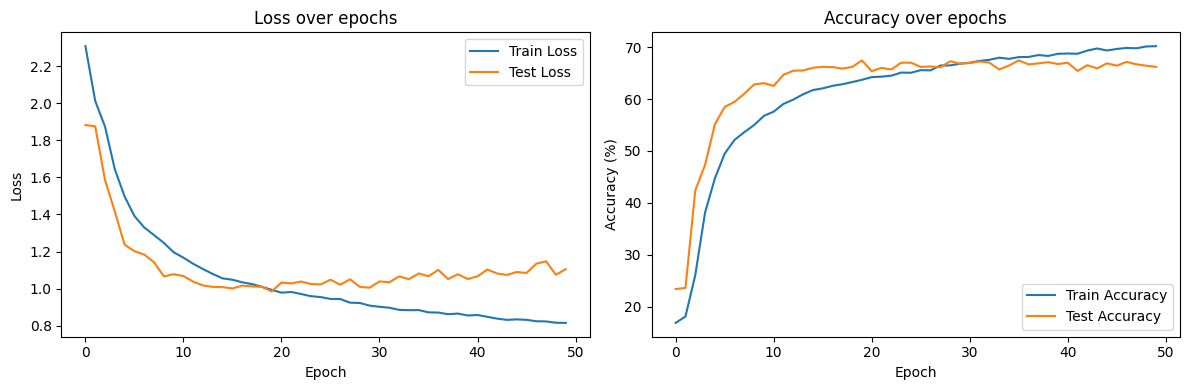

In [77]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(cnn_losses, label='Train Loss')
plt.plot(cnn_test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_accs, label='Train Accuracy')
plt.plot(cnn_test_accs, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy over epochs')
plt.legend()
plt.tight_layout()

plt.show()

# Оценка точности модели

Переключите модель в режим оценки и отключите вычисления градиента.
Для каждой тестовой партии вычислите прогнозы и подсчитайте количество правильных классификаций.
Вычислите и распечатайте общую точность в процентах от правильно классифицированных тестовых изображений.

Test Accuracy: 66.19%

Classification Report:
              precision    recall  f1-score   support

    airplane       0.71      0.74      0.73      1000
  automobile       0.86      0.71      0.78      1000
        bird       0.60      0.52      0.56      1000
         cat       0.45      0.38      0.41      1000
        deer       0.61      0.54      0.57      1000
         dog       0.52      0.69      0.59      1000
        frog       0.72      0.78      0.75      1000
       horse       0.61      0.76      0.68      1000
        ship       0.87      0.70      0.78      1000
       truck       0.73      0.79      0.76      1000

    accuracy                           0.66     10000
   macro avg       0.67      0.66      0.66     10000
weighted avg       0.67      0.66      0.66     10000



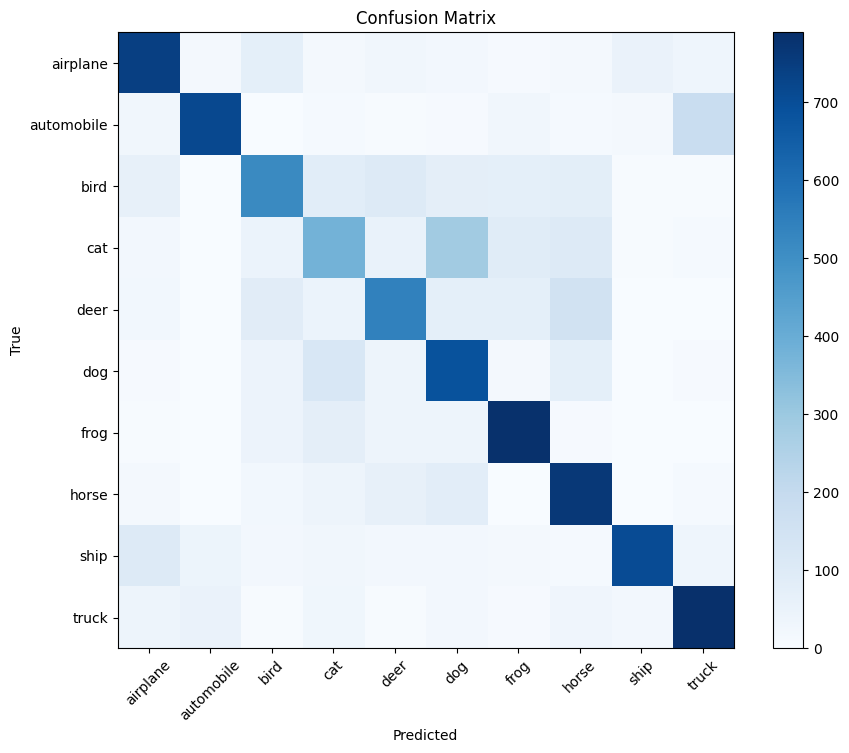

In [76]:
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loaders:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total
print(f'Test Accuracy: {accuracy:.2f}%')

from sklearn.metrics import classification_report, confusion_matrix
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(10), test_dataset.classes, rotation=45)
plt.yticks(range(10), test_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Визуализация прогнозов модели

Из тестовой партии выберите несколько изображений и соберите их фактические и прогнозируемые названия классов.
Отобразите эти изображения в виде сетки, указав в заголовке как фактические, так и прогнозируемые метки.

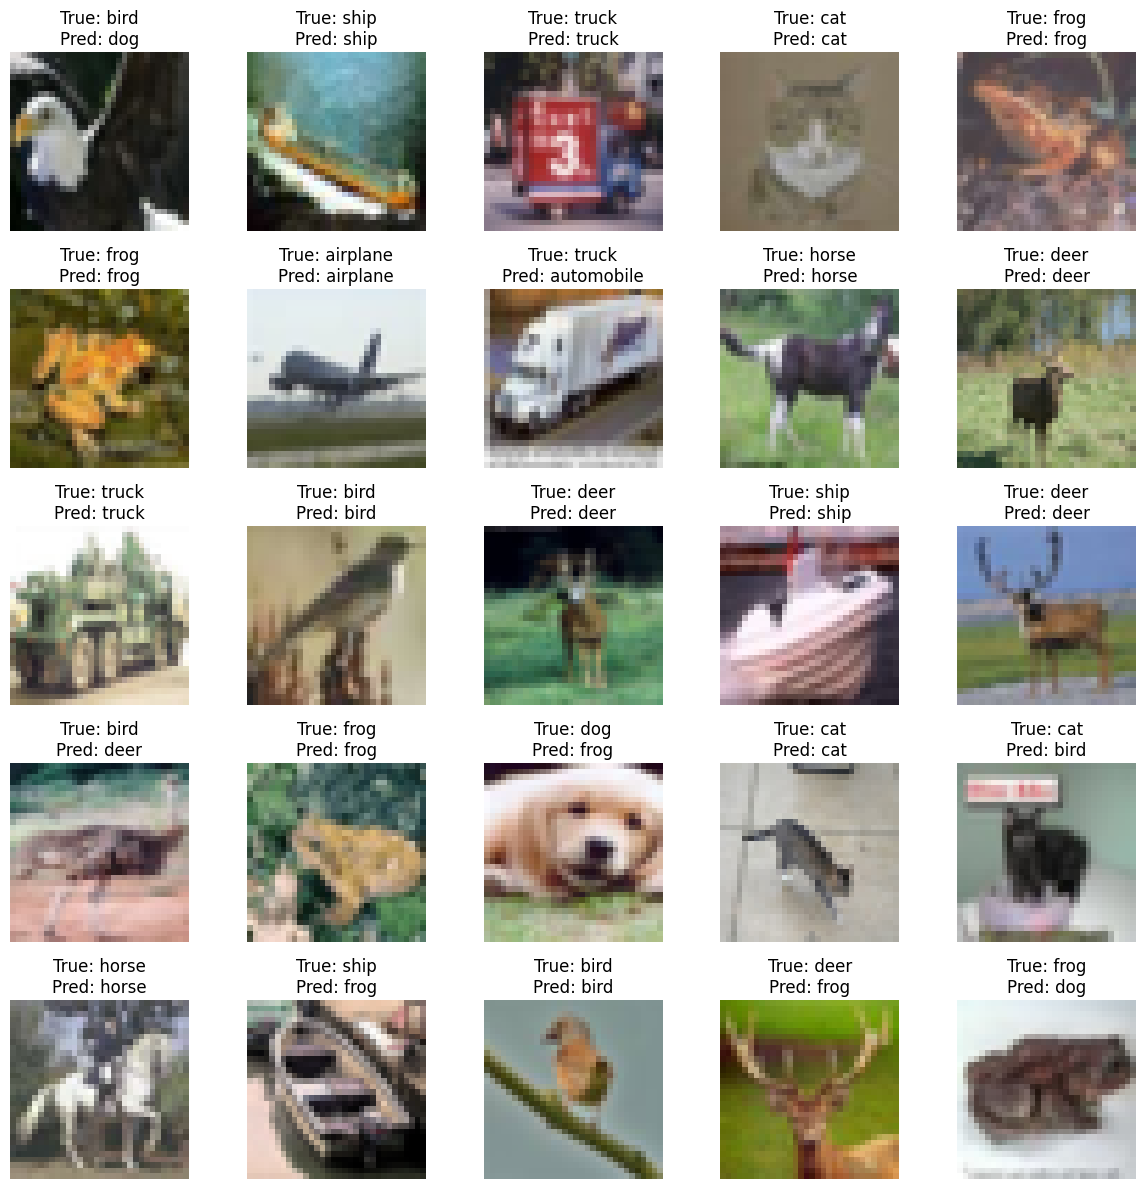

In [75]:
data_iter = iter(test_loaders)
images, labels = next(data_iter)
images = images[:25].to(device)
labels = labels[:25]

model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)
    predicted = predicted.cpu()
    labels = labels.cpu()

fig, axes = plt.subplots(5, 5, figsize=(12, 12))
axes = axes.flatten()

for i in range(25):
    img = images[i].cpu().numpy()
    img = img * 0.5 + 0.5
    img = np.clip(img, 0, 1)
    img = np.transpose(img, (1, 2, 0))
    axes[i].imshow(img)
    true_label = test_dataset.classes[labels[i]]
    pred_label = test_dataset.classes[predicted[i]]
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()